# Домашнее задание 3 - Проверка статистических гипотез и параметрические критерии

**ВАЖНО: Обязательно для каждой задачи строим график и показываем куда попадает наше значение, если в задаче нужно проверить статистическую гипотезу**
\
**При отсутствии графиков возможна полная потеря баллов за задание**

### Задача 1 (1 балл)

Пусть X1,X2,…,Xn​ — независимые и одинаково распределенные случайные величины из нормального распределения с неизвестным средним μ и известной дисперсией σ^2=25. Из выборки объема n=64 получено выборочное среднее =102.
\
Проверьте гипотезу H0:μ=100 против альтернативы H1:μ>100 на уровне значимости α=0.01.
\
Вычислите p-значение этого теста.

In [1]:
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt

In [33]:
from typing import Literal

def plot_z(
        z_score: float,
        z_critical: float,
        kind: Literal["left", "right", "both"] = "right",
        z_min: float = -4.,
        z_max: float = 4.
) -> None:
    z_value = np.linspace(z_min, z_max, 1000)
    pdf = stats.norm.pdf(z_value, 0, 1)
    plt.plot(z_value, pdf)
    
    plt.axvline(z_score, color='red', linestyle='--', label=f'Z-статистика = {z_score:.2f}')
    
    
    
    if kind == "left":
        plt.axvline(z_critical, color='blue', linestyle='--', label=f'Критические значения = {z_critical:.2f}')
        plt.fill_between(z_value, pdf, where=(z_value <= -abs(z_score)), color='red', alpha=0.5)
    elif kind == "right":
        plt.axvline(z_critical, color='blue', linestyle='--', label=f'Критические значения = {z_critical:.2f}')
        plt.fill_between(z_value, pdf, where=(z_value >= abs(z_score)), color='red', alpha=0.5)
    elif kind == "both":
        plt.axvline(abs(z_score), color='red', linestyle='--')
        plt.axvline(-abs(z_score), color='red', linestyle='--')
        plt.fill_between(z_value, pdf, where=(z_value <= -abs(z_score)), color='red', alpha=0.5)
        plt.fill_between(z_value, pdf, where=(z_value >= abs(z_score)), color='red', alpha=0.5)
        plt.axvline(-z_critical, color='blue', linestyle='--', label=f'Критические значения = ±{z_critical:.2f}')
        plt.axvline(z_critical, color='blue', linestyle='--')
    
    plt.xlim(z_min, z_max)
    plt.ylim(0, 0.5)

    plt.legend()
    plt.title('Стандартное нормальное распределение и Z-статистика')
    plt.xlabel('Z')
    plt.ylabel('Плотность вероятности')


def plot_t(
        t_score: float,
        t_critical: float,
        df: int,
        kind: Literal["left", "right", "both"] = "right",
        t_min: float = -4.,
        t_max: float = 4.
) -> None:
    t_value = np.linspace(t_min, t_max, 1000)
    pdf = stats.t.pdf(t_value, df)
    plt.plot(t_value, pdf)
    
    
    plt.axvline(t_score, color='red', linestyle='--', label=f't-статистика = {t_score:.2f}')
    
    if kind == "left":
        plt.axvline(t_critical, color='blue', linestyle='--', label=f'Критические значения = {t_critical:.2f}')
        plt.fill_between(t_value, pdf, where=(t_value <= t_score), color='red', alpha=0.5, label='p-значение')
    elif kind == "right":
        plt.axvline(t_critical, color='blue', linestyle='--', label=f'Критические значения = {t_critical:.2f}')
        plt.fill_between(t_value, pdf, where=(t_value >= abs(t_score)), color='red', alpha=0.5, label='p-значение')
    elif kind == "both":
        plt.axvline(abs(t_score), color='red', linestyle='--')
        plt.axvline(-abs(t_score), color='red', linestyle='--')
        plt.axvline(-abs(t_critical), color='blue', linestyle='--', label=f'Критические значения = +-{t_critical:.2f}')
        plt.axvline(abs(t_critical), color='blue', linestyle='--')

        plt.fill_between(t_value, pdf, where=(t_value <= -abs(t_score)), color='red', alpha=0.5, label='p-значение')
        plt.fill_between(t_value, pdf, where=(t_value >= abs(t_score)), color='red', alpha=0.5)
    
    
    plt.xlim(t_min, t_max)
    plt.ylim(0, 0.5)

    plt.legend()
    plt.title('Стандартное нормальное распределение и t-статистика')
    plt.xlabel('t')
    plt.ylabel('Плотность вероятности')

Статистика теста Z: 3.2000
Критическое значение Z для α = 0.01: 2.3263
p-значение: 0.0007
Отвергаем нулевую гипотезу H0.


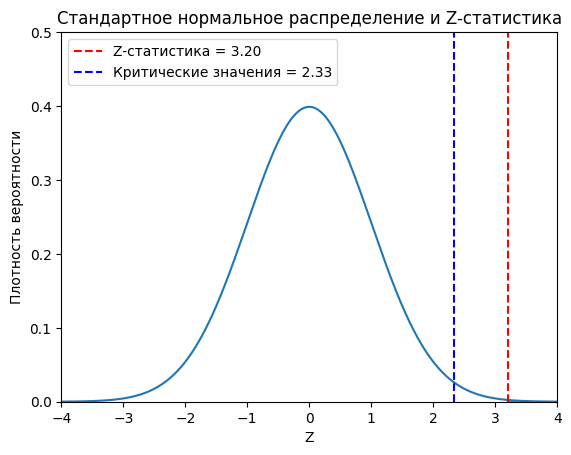

In [34]:
alpha = 0.01

mu_0 = 100
sigma = 5
n = 64
sample_mean = 102

z_score = (sample_mean - mu_0) / (sigma / np.sqrt(n))
critical_value = stats.norm.ppf(1 - alpha)
p_value = 1 - stats.norm.cdf(z_score)

print(f"Статистика теста Z: {z_score:.4f}")
print(f"Критическое значение Z для α = {alpha}: {critical_value:.4f}")
print(f"p-значение: {p_value:.4f}")

if z_score > critical_value:
    print("Отвергаем нулевую гипотезу H0.")
else:
    print("Не отвергаем нулевую гипотезу H0.")

plot_z(
    z_score=z_score,
    z_critical=critical_value,
    kind='right'
)

### Задача 2 (1 балл)

Даны три независимые выборки. Первая выборка объемом 35 наблюдений имеет выборочное среднее 10.2 и выборочную дисперсию 2.5. Вторая выборка объемом 30 наблюдений имеет выборочное среднее 9.8 и выборочную дисперсию 2.8. Третья выборка объемом 40 наблюдений имеет выборочное среднее 10.5 и выборочную дисперсию 3.0.

Проверьте гипотезу о том, что средние всех трех выборок равны, на уровне значимости 0.05.
Оцените статистическую значимость результатов и постройте доверительные интервалы c графиками для каждого из средних.

**Использовать попарное сравнение для получения результата**

In [35]:
from typing import Tuple

ns = (35, 30, 40)
sample_means = (10.2, 9.8, 10.5)
ss = (np.sqrt(2.5), np.sqrt(2.8), np.sqrt(3.))

def confidence_interval(sample_mean, s, n, alpha) -> Tuple[float, float]:
    t = stats.t.ppf(1 - alpha / 2, n - 1)
    interval = (float(sample_mean - t * s / np.sqrt(n)), float(sample_mean + t * s / np.sqrt(n)))
    return interval

def t_test(
        n1: int,
        n2: int,
        sample_mean1: float,
        sample_mean2: float,
        s1: float,
        s2: float,
        alpha: float = .05
) -> np.float32:
    t12 = (sample_mean1 - sample_mean2) / np.sqrt((s1**2 / n1) + (s2**2 / n2))
    df = ((sample_mean1**2 / n1 + sample_mean2**2 / n2)**2) / (((sample_mean1**2 / n1)**2) / (n1 - 1) + ((sample_mean2**2 / n2)**2) / (n2 - 1))
    p12 = (1 - stats.t.cdf(abs(t12), df)) * 2
    if alpha > p12:
        print(f"Отвергаем нулевую гипотезу: p-значение: {p12:.4f}, alpha: {alpha}")
    print(f"Не отвергаем нулевую гипотезу: p-значение: {p12:.4f}, alpha: {alpha}")
    return p12, t12, df

t-тест для пары 1 и 2
Не отвергаем нулевую гипотезу: p-значение: 0.3282, alpha: 0.05


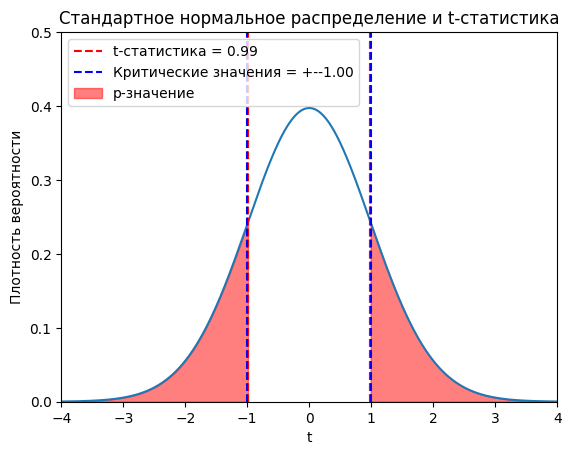

t-тест для пары 1 и 3
Не отвергаем нулевую гипотезу: p-значение: 0.4356, alpha: 0.05


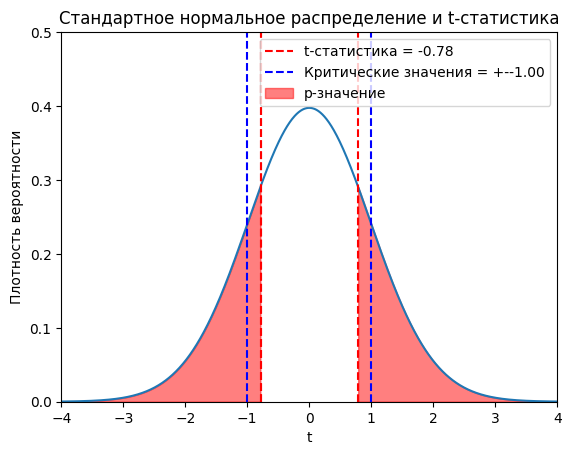

t-тест для пары 2 и 3
Не отвергаем нулевую гипотезу: p-значение: 0.0928, alpha: 0.05


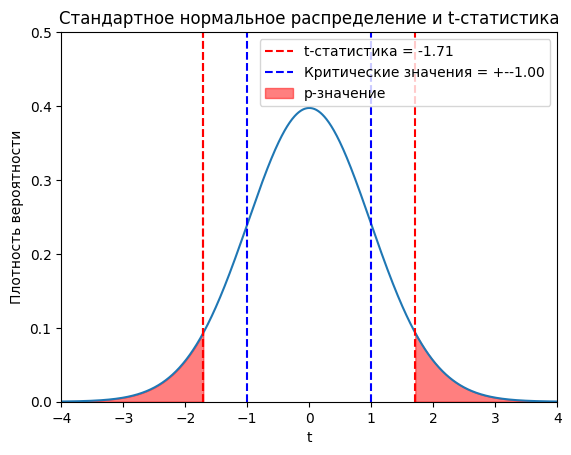

9.66, 10.74: Доверительный интервал для выборочного среднего 1-й выборки
9.18, 10.42: Доверительный интервал для выборочного среднего 2-й выборки
9.95, 11.05: Доверительный интервал для выборочного среднего 3-й выборки


In [36]:
alpha = .05
ps = []
for i in range(len(ns)):
    for j in range(i + 1, len(ns)):
        print(f"t-тест для пары {i + 1} и {j + 1}")
        p, t_score, df = t_test(ns[i], ns[j], sample_means[i], sample_means[j], ss[i], ss[j], alpha=alpha)
        ps.append(p)
        plot_t(
            t_score=t_score,
            t_critical=-1,
            kind='both',
            df=df
        )
        plt.show()

for i in range(len(ns)):
    l, r = confidence_interval(sample_means[i], ss[i], ns[i], alpha)
    print(f"{l:.2f}, {r:.2f}: Доверительный интервал для выборочного среднего {i+1}-й выборки")

In [37]:
if all(map(lambda p: p > alpha, ps)):
    print("Принимаем нулевую гипотезу H0.")
else:
    print("Отвергаем нулевую гипотезу H0.")


Принимаем нулевую гипотезу H0.


### Задача 3 (1 балл)

Тестирование параметра распределения Пуассона

Выборка из 60 наблюдений была получена из распределения Пуассона с неизвестным параметром. Известно, что среднее количество наблюдений в выборке равно 4.8.

Проверьте гипотезу о том, что параметр распределения Пуассона равен 5 против альтернативы, что он меньше 5. Используйте уровень значимости 0.05.
Вычислите p-значение и сделайте вывод о гипотезе.

Статистика теста Z: -0.6928
p-значение: 0.2442
Не отвергаем нулевую гипотезу H0. lambda < 5


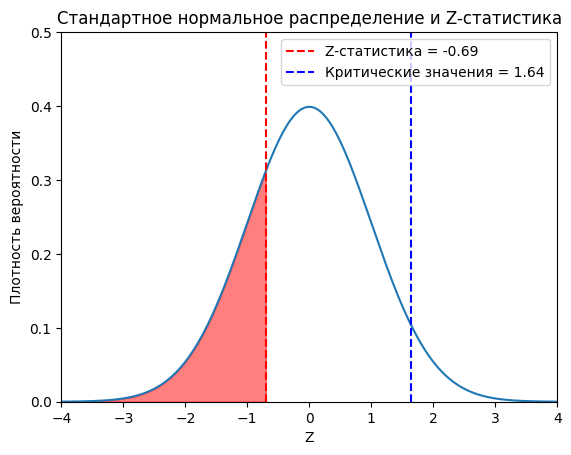

In [38]:
alpha = 0.05

n = 60
sample_mean = 4.8
lambda_0 = 5

z_score = (sample_mean - lambda_0) / np.sqrt(lambda_0 / n)

p_value = stats.norm.cdf(z_score)

print(f"Статистика теста Z: {z_score:.4f}")
print(f"p-значение: {p_value:.4f}")

if p_value < alpha:
    print("Отвергаем нулевую гипотезу H0. lambda = 5")
else:
    print("Не отвергаем нулевую гипотезу H0. lambda < 5")

plot_z(
    z_score=z_score,
    z_critical = stats.norm.ppf(1 - alpha),
    kind='left'
)

### Задача 4 (1 балл)

Компания заявляет, что среднее время работы их нового аккумулятора составляет 100 часов. Независимая лаборатория протестировала 25 случайно выбранных аккумуляторов и получила среднее время работы 95 часов при стандартном отклонении 10 часов. Можно ли на уровне значимости 1% утверждать, что реальное среднее время работы аккумуляторов меньше заявленного?

Статистика теста Z: -2.5000
Критическое значение Z для α = 0.01: -2.3263
p-значение: 0.0062
Отвергаем нулевую гипотезу H0. mean work time 100h


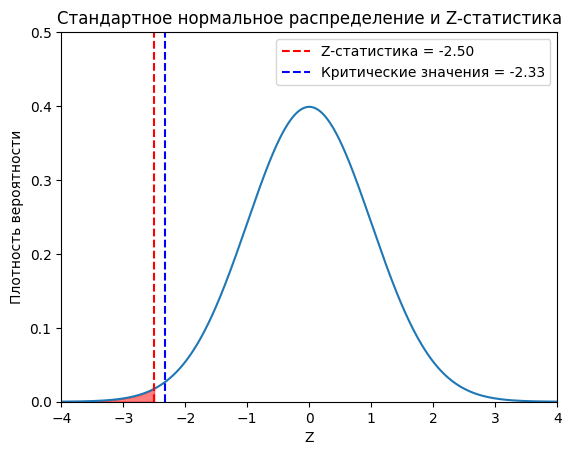

In [39]:
alpha = 0.01

n = 25
sample_mean = 95
population_mean = 100
sample_std = 10

z_score = (sample_mean - population_mean) / (sample_std / np.sqrt(n))
p_value = stats.norm.cdf(z_score)
critical_value = stats.norm.ppf(alpha)

print(f"Статистика теста Z: {z_score:.4f}")
print(f"Критическое значение Z для α = {alpha}: {critical_value:.4f}")
print(f"p-значение: {p_value:.4f}")

if p_value < alpha:
    print("Отвергаем нулевую гипотезу H0. mean work time 100h")
else:
    print("Не отвергаем нулевую гипотезу H0. mean work time < 100h")
    
plot_z(
    z_score=z_score,
    z_critical=critical_value,
    kind='left'
)

### Задача 5 (1 балл)

В ходе медицинского исследования сравнивается эффективность нового препарата для снижения артериального давления с существующим. Первой группе из 30 пациентов назначают новый препарат, и среднее снижение давления составляет 8 мм рт. ст. со стандартным отклонением 2 мм рт. ст. Второй группе из 30 пациентов дают существующий препарат, и среднее снижение составляет 6 мм рт. ст. со стандартным отклонением 3 мм рт. ст. Является ли новый препарат более эффективным на уровне значимости 5%?

Статистика теста t: 3.0382
Критическое значение t для α = 0.05: 1.6756
p-значение: 0.0019
Не отвергаем нулевую гипотезу H0. mean1 > mean2


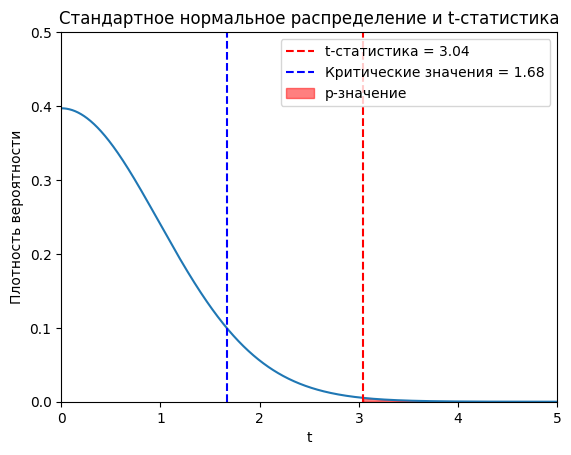

In [40]:
alpha = 0.05

n1 = 30
mean1 = 8
std1 = 2

n2 = 30
mean2 = 6
std2 = 3

t_score = (mean1 - mean2) / np.sqrt((std1**2 / n1) + (std2**2 / n2))
df = ((std1**2 / n1 + std2**2 / n2)**2) / (((std1**2 / n1)**2) / (n1 - 1) + ((std2**2 / n2)**2) / (n2 - 1))
critical_value = stats.t.ppf(1 - alpha, df)
p_value = 1 - stats.t.cdf(t_score, df)

print(f"Статистика теста t: {t_score:.4f}")
print(f"Критическое значение t для α = {alpha}: {critical_value:.4f}")
print(f"p-значение: {p_value:.4f}")

if t_score < critical_value:
    print("Отвергаем нулевую гипотезу H0(mean1 = mean2).")
else:
    print("Не отвергаем нулевую гипотезу H0. mean1 > mean2")

plot_t(
    t_score=t_score,
    t_critical=critical_value,
    kind='right',
    t_min=0.,
    t_max=5.,
    df=df
)

### Задача 6 (1 балл)

В университете внедрили новую методику преподавания математики и хотят оценить ее влияние на успеваемость студентов. Средний балл по математике в предыдущие годы был 75. После внедрения методики группа из 50 студентов получила средний балл 78 с стандартным отклонением 5. Проверить на уровне значимости 1%, улучшилась ли успеваемость студентов.

Статистика теста Z: 4.2426
Критическое значение Z для α = 0.01: 2.3263
p-значение: 0.0000
Отвергаем нулевую гипотезу H0(успеваемость не изменилась).


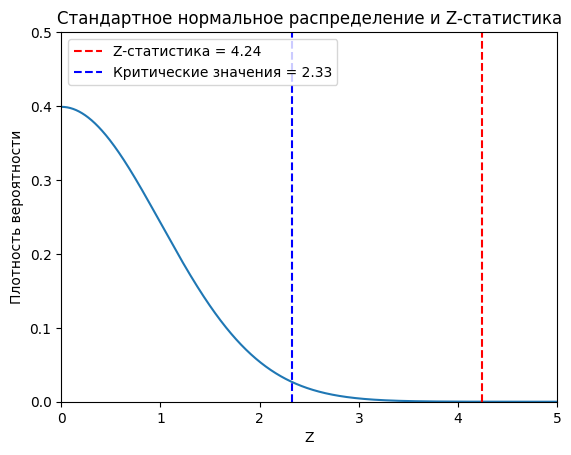

In [41]:
alpha = 0.01

n = 50
mean_sample = 78
std_sample = 5
mean_historical = 75

z_score = (mean_sample - mean_historical) / (std_sample / np.sqrt(n))

critical_value = stats.norm.ppf(1 - alpha)

p_value = 1 - stats.norm.cdf(z_score)

print(f"Статистика теста Z: {z_score:.4f}")
print(f"Критическое значение Z для α = {alpha}: {critical_value:.4f}")
print(f"p-значение: {p_value:.4f}")

if p_value < alpha:
    print("Отвергаем нулевую гипотезу H0(успеваемость не изменилась).")
else:
    print("Не отвергаем нулевую гипотезу H0. успеваемость улучшилась")

plot_z(
    z_score=z_score,
    z_critical=critical_value,
    kind='right',
    z_min=0.,
    z_max=5.
)

### Задача 7 (1 балл)

Производитель утверждает, что его новый процессор работает на 20% быстрее предыдущей модели. Для проверки этого заявления были протестированы 40 новых и 40 старых процессоров. Новые процессоры в среднем выполняли задачу за 8 секунд с стандартным отклонением 1 секунда, старые — за 10 секунд с стандартным отклонением 1,5 секунды. Соответствует ли утверждение производителя действительности на уровне значимости 2%?

новый процессор работает быстрее на 20%


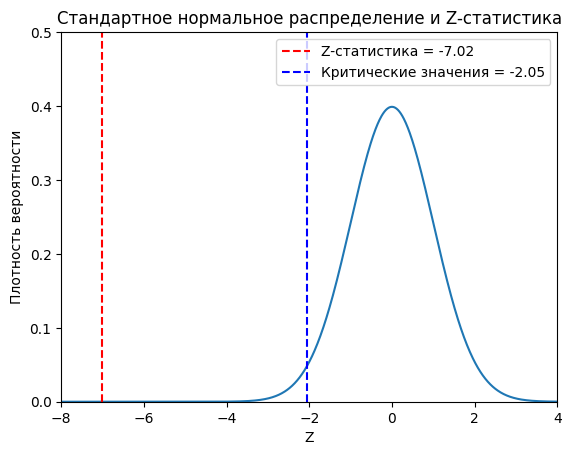

In [42]:
alpha = 0.02

n1, sample_mean1, sigma1 = 40, 8, 1
n2, sample_mean2, sigma2 = 40, 10, 1.5

z_score = (sample_mean1 - sample_mean2) / np.sqrt((sigma1**2 / n1) + (sigma2**2 / n2))
critical_value = stats.norm.ppf(alpha)

p_value = stats.norm.cdf(z_score)

if p_value < alpha:
    print("новый процессор работает быстрее на 20%")
else:
    print("Утверждение производителя не соответствует действительности")

plot_z(
    z_score,
    critical_value,
    kind='left',
    z_min=-8
)

### Задача 8 (1 балл)

После введения новых экологических стандартов исследователь хочет определить, снизился ли уровень загрязнения воздуха в городе. До введения стандартов средняя концентрация вредных веществ составляла 50 мкг/м³. Через год после внедрения было проведено 36 измерений, и средняя концентрация составила 47 мкг/м³ со стандартным отклонением 4 мкг/м³. Можно ли на уровне значимости 5% считать, что уровень загрязнения воздуха снизился?

z-статистика: -4.5000
Критическое значение: -1.6449
Отвергаем нулевую гипотезу: уровень загрязнения воздуха снизился.


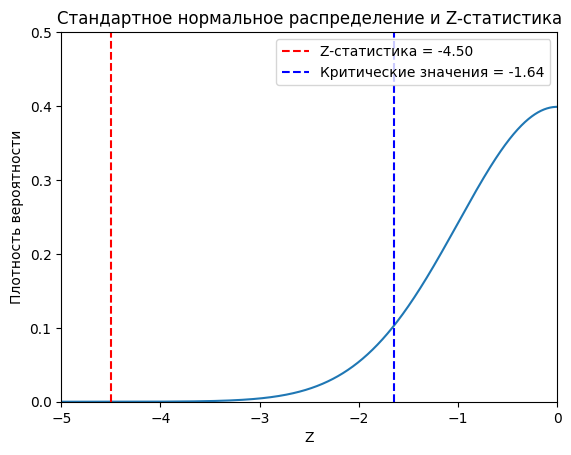

In [43]:
alpha = 0.05

mu_0 = 50
M = 47
SD = 4
n = 36


z_score = (M - mu_0) / (SD / np.sqrt(n))

critical_value = stats.norm.ppf(alpha)

print(f"z-статистика: {z_score:.4f}")
print(f"Критическое значение: {critical_value:.4f}")

if z_score < critical_value:
    print("Отвергаем нулевую гипотезу: уровень загрязнения воздуха снизился.")
else:
    print("Не отвергаем нулевую гипотезу: нет достаточных оснований считать, что уровень загрязнения воздуха снизился.")

plot_z(
    z_score=z_score,
    z_critical=critical_value,
    kind='left',
    z_min=-5,
    z_max=0.
)

### Задача 9 (1 балл)

В школе проводят эксперимент, чтобы выяснить, влияет ли дополнительное занятие по чтению на скорость чтения учеников. Учеников случайным образом разделили на две группы по 20 человек. Первая группа занималась по стандартной программе и показала среднюю скорость чтения 150 слов в минуту со стандартным отклонением 15 слов. Вторая группа посещала дополнительные занятия и показала среднюю скорость 160 слов в минуту со стандартным отклонением 10 слов. Является ли разница в скоростях статистически значимой на уровне значимости 5%?

Отвергаем нулевую гипотезу: разница в скоростях чтения статистически значима.


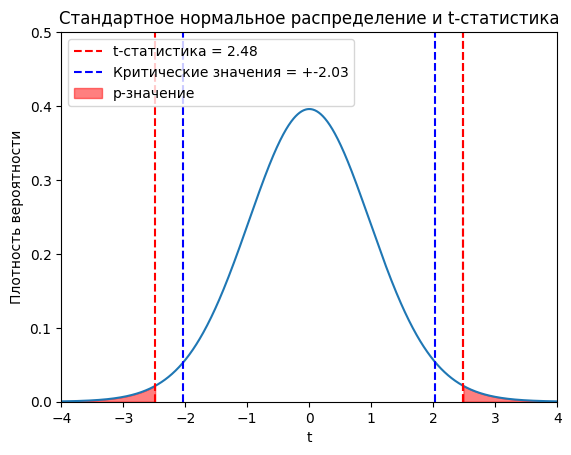

In [44]:
alpha = 0.05

n1 = 20
n2 = 20

mean1 = 150
std1 = 15

mean2 = 160
std2 = 10

df = ((std1**2 / n1 + std2**2 / n2)**2) / (((std1**2 / n1)**2) / (n1 - 1) + ((std2**2 / n2)**2) / (n2 - 1))

t_score = (mean2 - mean1) / np.sqrt((std1**2 / n1) + (std2**2 / n2))
critical_value = stats.t.ppf(1 - alpha / 2, df)

p_value = 2 * (1 - stats.t.cdf(abs(t_score), df))

if p_value < alpha:
    print("Отвергаем нулевую гипотезу: разница в скоростях чтения статистически значима.")
else:
    print("Не отвергаем нулевую гипотезу: нет достаточных оснований считать, что разница в скоростях чтения статистически значима.")

plot_t(
    t_score,
    critical_value,
    df=df,
    kind='both',
)

### Задача 10 (1 балл)

Автомобильная компания хочет определить, влияет ли новый тип топлива на эффективность расхода топлива. В тесте участвовали 30 автомобилей, использующих обычное топливо, и 30 автомобилей на новом топливе. Средний расход для обычного топлива составил 8 литров на 100 км с стандартным отклонением 0,5 литра, для нового топлива — 7,5 литров на 100 км с стандартным отклонением 0,4 литра. Проверьте на уровне значимости 1%, улучшает ли новый тип топлива эффективность.

Новый тип топлива не улучшает эффективность расхода топлива


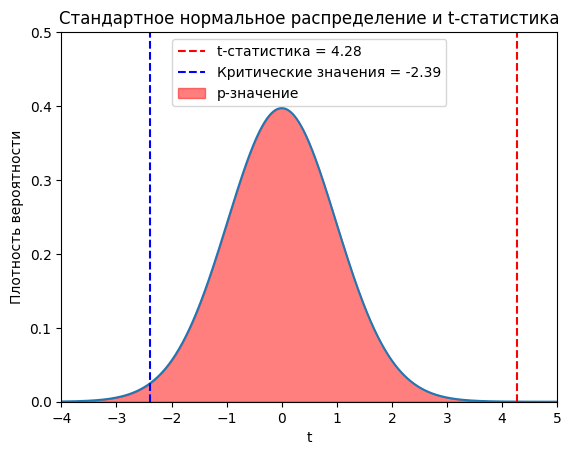

In [45]:
alpha = 0.01

n1, sample_mean1, s1 = 30, 8, 0.5
n2, sample_mean2, s2 = 30, 7.5, 0.4

df = n1 + n2 - 2

s_p = ((n1 - 1) * s1**2 + (n2 - 1) * s2**2) / df
se  = np.sqrt(s_p * (1 / n1 + 1 / n2))

t_score = (sample_mean1 - sample_mean2) / se

critical_value = stats.t.ppf(alpha, df)

p_value = stats.t.cdf(t_score, df)


if t_score < critical_value:
    print("Новый тип топлива улучшает эффективность расхода топлива")
else:
    print("Новый тип топлива не улучшает эффективность расхода топлива")


plot_t(
    t_score,
    critical_value,
    df=df,
    kind='left',
    t_max=5.
)

### Задача 11 (1 балл)

В исследовании психологии изучается влияние медитации на уровень стресса. Уровень стресса измеряется по шкале от 0 до 100. До начала программы медитации у группы из 25 участников средний уровень стресса был 70 с стандартным отклонением 8. После программы средний уровень снизился до 65 с стандартным отклонением 7. Является ли снижение уровня стресса статистически значимым на уровне значимости 5%?

Не отвергаем нулевую гипотезу: нет достаточных оснований считать, что уровень стресса снизился.


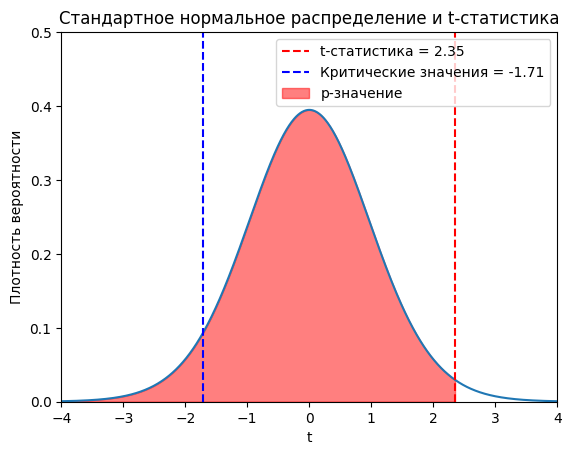

In [46]:
alpha = .05

n = 25
mean_before = 70
std_before = 8

mean_after = 65
std_after = 7

t_score = (mean_before - mean_after) / np.sqrt((std_before**2 / n) + (std_after**2 / n))
df = n - 1

p_value = stats.t.cdf(t_score, df)

t_critical = stats.t.ppf(alpha, df)


if p_value < alpha:
    print("Отвергаем нулевую гипотезу: снижение уровня стресса статистически значимо.")
else:
    print("Не отвергаем нулевую гипотезу: нет достаточных оснований считать, что уровень стресса снизился.")


plot_t(
    t_score,
    t_critical,
    df,
    kind='left'
)

### Задача 12 (1 балл)

Компания по производству напитков изменила рецепт своего продукта и хочет определить, повлияло ли это на предпочтения потребителей. В тестировании участвовали 200 человек, из которых 110 предпочли новый рецепт, а остальные остались нейтральны или выбрали старый. Можно ли на уровне значимости 1% утверждать, что большинство потребителей предпочитают новый рецепт?

Z-статистика: 1.4142
p-значение: 0.0786
Не отвергаем нулевую гипотезу: нет достаточных оснований утверждать, что большинство предпочитает новый рецепт.


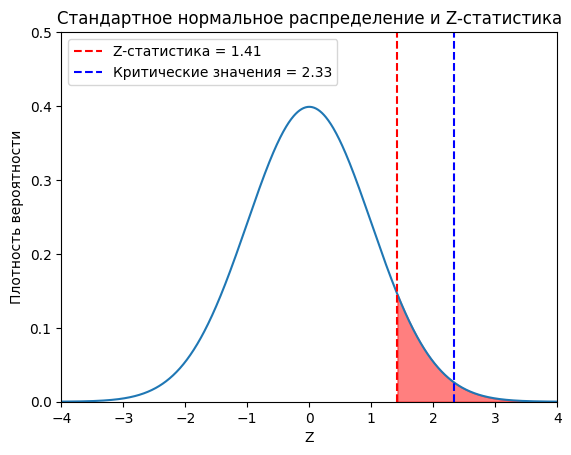

In [47]:
alpha = 0.01

n = 200
x = 110

p_hat = x / n

p0 = 0.5

std_error = np.sqrt(p0 * (1 - p0) / n)

z_score = (p_hat - p0) / std_error
z_critical = stats.norm.ppf(1 - alpha)
p_value = 1 - stats.norm.cdf(z_score)

print(f"Z-статистика: {z_score:.4f}")
print(f"p-значение: {p_value:.4f}")

# Проверка гипотезы
if p_value < alpha:
    print("Отвергаем нулевую гипотезу: большинство потребителей предпочитают новый рецепт.")
else:
    print("Не отвергаем нулевую гипотезу: нет достаточных оснований утверждать, что большинство предпочитает новый рецепт.")

plot_z(
    z_score,
    z_critical,
    kind='right'
)

### Задача 13 (1 балл)

В ходе эксперимента изучается влияние нового удобрения на рост растений. Группе из 15 растений добавляли новое удобрение, и средний рост составил 25 см с стандартным отклонением 3 см. Контрольная группа из 15 растений без удобрения показала средний рост 22 см с стандартным отклонением 2,5 см. Проверить на уровне значимости 5%, является ли разница в росте статистически значимой.

t-статистика: 2.9753
p-значение: 0.0060
Отвергаем нулевую гипотезу: разница в росте статистически значима.


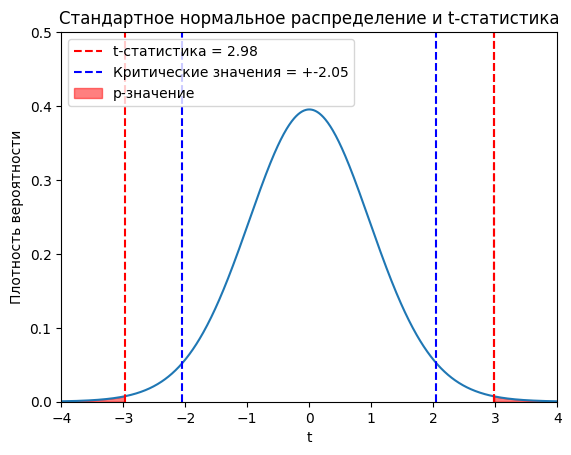

In [48]:
alpha = 0.05

n1 = 15
mean1 = 25
std1 = 3

n2 = 15
mean2 = 22
std2 = 2.5

t_score = (mean1 - mean2) / np.sqrt((std1**2 / n1) + (std2**2 / n2))
df = n1 + n2 - 2
p_value = 2*(1 - stats.t.cdf(abs(t_score), df))
t_critical = stats.t.ppf(1 - alpha / 2, df)

print(f"t-статистика: {t_score:.4f}")
print(f"p-значение: {p_value:.4f}")

# Проверка гипотезы
if p_value < alpha:
    print("Отвергаем нулевую гипотезу: разница в росте статистически значима.")
else:
    print("Не отвергаем нулевую гипотезу: нет достаточных оснований утверждать, что разница в росте статистически значима.")

plot_t(
    t_score,
    t_critical,
    df=df,
    kind='both'
)

### Задача 14 (5 баллов за все пункты)

Пункт 1. Компания внедряет новую программу обучения сотрудников с целью повышения производительности труда. Ранее средняя производительность составляла 50 единиц в день при стандартном отклонении 8 единиц. После года действия программы случайно выбранная выборка из 80 сотрудников показала среднюю производительность 52 единицы. Считаем, что стандартное отклонение осталось неизменным. Можно ли на основе этих данных утверждать, что программа обучения действительно повысила производительность, или наблюдаемый результат мог возникнуть случайно? Сформулируйте нулевую и альтернативную гипотезы, определите тип теста (двусторонний, левосторонний или правосторонний) и проверьте нулевую гипотезу на уровнях значимости α = 1% и α = 5%.


---

Пункт 2. Решите пункт 1, если выборка состоит лишь из 5 сотрудников.


---

Пункт 3. Решите пункт 1 при условии, что стандартное отклонение увеличилось до 16 единиц.


---

Пункт 4. Решите пункт 1, если после внедрения программы средняя производительность составила 51 единицу.


---

Пункт 5. Решите пункт 1, если стандартное отклонение неизвестно, а выборка составила 25 сотрудников. Несмещённая оценка дисперсии выборки составила 64. Примите уровень значимости равным 5%.

Z-статистика: 2.2361
p-значение: 0.0127
Нет оснований отклонить нулевую гипотезу H0 с уровнем значимости 1% : средняя производительность не изменилась
Отклоняем нулевую гипотезу H0 с уровнем значимости 5% и принимаем новую гипотезу: средняя производительность увеличилась


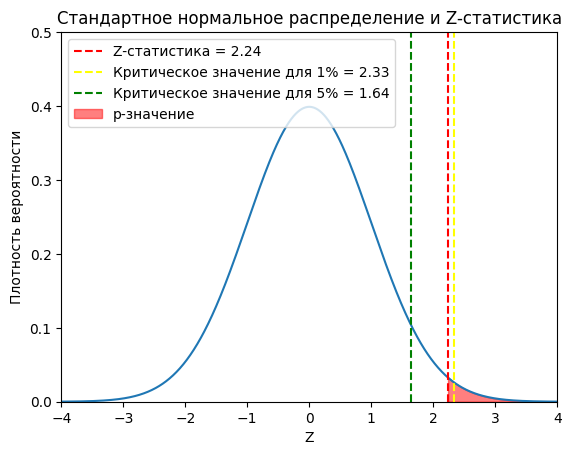

In [57]:
mean = 50
std = 8
sample_n = 80
sample_mean = 52
sample_std = std


alphas = (.01, .05)

"""
H0 : Средняя производительность не изменилась (=)
H1 : Средняя производительность увеличилась (>)
"""

#1 
z_score = (sample_mean - mean) / (sample_std / np.sqrt(sample_n))
p_value = 1 - stats.norm.cdf(z_score)

print(f"Z-статистика: {z_score:.4f}")
print(f"p-значение: {p_value:.4f}")


def compare(p_value: float, alpha: float) -> None:
    if p_value < alpha:
        print(f"Отклоняем нулевую гипотезу H0 с уровнем значимости {alpha*100:.0f}% и принимаем новую гипотезу: средняя производительность увеличилась")
    else:
        print(f"Нет оснований отклонить нулевую гипотезу H0 с уровнем значимости {alpha*100:.0f}% : средняя производительность не изменилась")

for alpha in alphas: 
    compare(p_value, alpha)


z_min, z_max = -4, 4
z_value = np.linspace(z_min, z_max, 1000)
pdf = stats.norm.pdf(z_value, 0, 1)
plt.plot(z_value, pdf)

plt.axvline(z_score, color='red', linestyle='--', label=f'Z-статистика = {z_score:.2f}')

for alpha, color in zip(alphas, ('yellow', 'green')):
    z_crit = stats.norm.ppf(1-alpha)
    plt.axvline(z_crit, color=color, linestyle='--', label=f'Критическое значение для {alpha*100:.0f}% = {z_crit:.2f}')

plt.fill_between(z_value, pdf, where=(z_value >= abs(z_score)), color='red', alpha=0.5, label='p-значение')

plt.xlim(z_min, z_max)
plt.ylim(0, 0.5)
plt.legend()
plt.title('Стандартное нормальное распределение и Z-статистика')
plt.xlabel('Z')
_ = plt.ylabel('Плотность вероятности')


t-статистика: 0.5590
p-значение: 0.2884
Нет оснований отклонить нулевую гипотезу H0 с уровнем значимости 1% : средняя производительность не изменилась
Нет оснований отклонить нулевую гипотезу H0 с уровнем значимости 5% : средняя производительность не изменилась


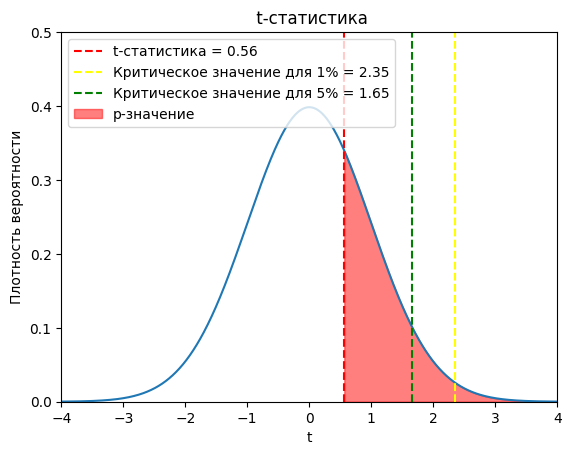

In [58]:
#2 
sample_n = 5 

t_score = (sample_mean - mean) / (sample_std / np.sqrt(sample_n))
df = n-1
p_value = 1 - stats.t.cdf(t_score, df)

print(f"t-статистика: {t_score:.4f}")
print(f"p-значение: {p_value:.4f}")

for alpha in alphas: 
    compare(p_value, alpha)


t_min, t_max = -4, 4
t_value = np.linspace(t_min, t_max, 1000)
pdf = stats.t.pdf(t_value, df)
plt.plot(t_value, pdf)

plt.axvline(t_score, color='red', linestyle='--', label=f't-статистика = {t_score:.2f}')

for alpha, color in zip(alphas, ('yellow', 'green')):
    t_crit = stats.t.ppf(1-alpha, df)
    plt.axvline(t_crit, color=color, linestyle='--', label=f'Критическое значение для {alpha*100:.0f}% = {t_crit:.2f}')

plt.fill_between(t_value, pdf, where=(t_value >= abs(t_score)), color='red', alpha=0.5, label='p-значение')

plt.xlim(t_min, t_max)
plt.ylim(0, 0.5)
plt.legend()
plt.title(' t-статистика')
plt.xlabel('t')
_ = plt.ylabel('Плотность вероятности')

Z-статистика: 1.1180
p-значение: 0.1318
Нет оснований отклонить нулевую гипотезу H0 с уровнем значимости 1% : средняя производительность не изменилась
Нет оснований отклонить нулевую гипотезу H0 с уровнем значимости 5% : средняя производительность не изменилась


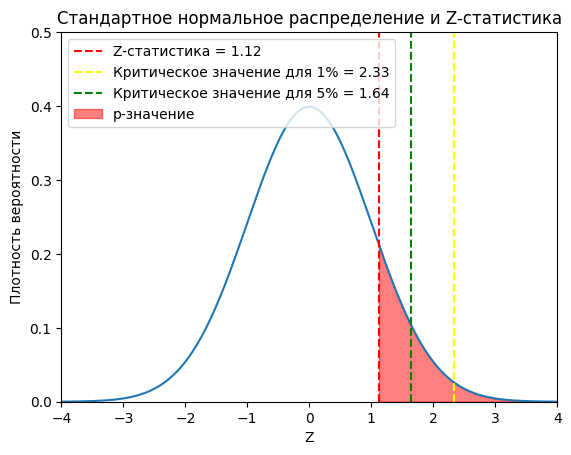

In [59]:
#3
sample_std = 16
sample_n = 80


z_score = (sample_mean - mean) / (sample_std / np.sqrt(sample_n))
p_value = 1 - stats.norm.cdf(z_score)

print(f"Z-статистика: {z_score:.4f}")
print(f"p-значение: {p_value:.4f}")

for alpha in alphas: 
    compare(p_value, alpha)


z_min, z_max = -4, 4
z_value = np.linspace(z_min, z_max, 1000)
pdf = stats.norm.pdf(z_value, 0, 1)
plt.plot(z_value, pdf)

plt.axvline(z_score, color='red', linestyle='--', label=f'Z-статистика = {z_score:.2f}')

for alpha, color in zip(alphas, ('yellow', 'green')):
    z_crit = stats.norm.ppf(1-alpha)
    plt.axvline(z_crit, color=color, linestyle='--', label=f'Критическое значение для {alpha*100:.0f}% = {z_crit:.2f}')

plt.fill_between(z_value, pdf, where=(z_value >= abs(z_score)), color='red', alpha=0.5, label='p-значение')

plt.xlim(z_min, z_max)
plt.ylim(0, 0.5)
plt.legend()
plt.title('Стандартное нормальное распределение и Z-статистика')
plt.xlabel('Z')
_ = plt.ylabel('Плотность вероятности')

Z-статистика: 1.1180
p-значение: 0.1318
Нет оснований отклонить нулевую гипотезу H0 с уровнем значимости 1% : средняя производительность не изменилась
Нет оснований отклонить нулевую гипотезу H0 с уровнем значимости 5% : средняя производительность не изменилась


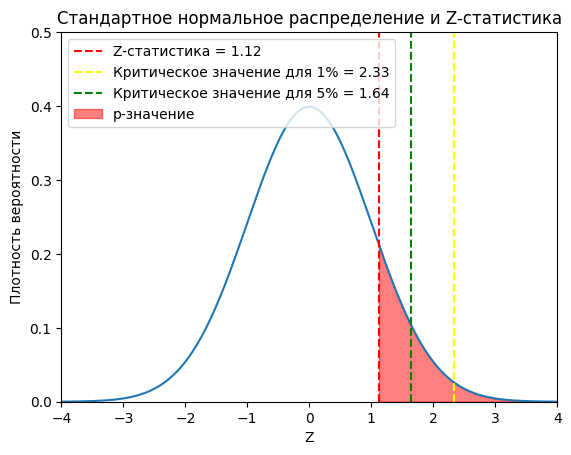

In [60]:
#4
mean = 50
std = 8
sample_n = 80
sample_mean = 51
sample_std = std

z_score = (sample_mean - mean) / (sample_std / np.sqrt(sample_n))
p_value = 1 - stats.norm.cdf(z_score)

print(f"Z-статистика: {z_score:.4f}")
print(f"p-значение: {p_value:.4f}")

for alpha in alphas: 
    compare(p_value, alpha)


z_min, z_max = -4, 4
z_value = np.linspace(z_min, z_max, 1000)
pdf = stats.norm.pdf(z_value, 0, 1)
plt.plot(z_value, pdf)

plt.axvline(z_score, color='red', linestyle='--', label=f'Z-статистика = {z_score:.2f}')

for alpha, color in zip(alphas, ('yellow', 'green')):
    z_crit = stats.norm.ppf(1-alpha)
    plt.axvline(z_crit, color=color, linestyle='--', label=f'Критическое значение для {alpha*100:.0f}% = {z_crit:.2f}')

plt.fill_between(z_value, pdf, where=(z_value >= abs(z_score)), color='red', alpha=0.5, label='p-значение')

plt.xlim(z_min, z_max)
plt.ylim(0, 0.5)
plt.legend()
plt.title('Стандартное нормальное распределение и Z-статистика')
plt.xlabel('Z')
_ = plt.ylabel('Плотность вероятности')

t-статистика: 1.2500
p-значение: 0.1064
Нет оснований отклонить нулевую гипотезу H0 с уровнем значимости 5% : средняя производительность не изменилась


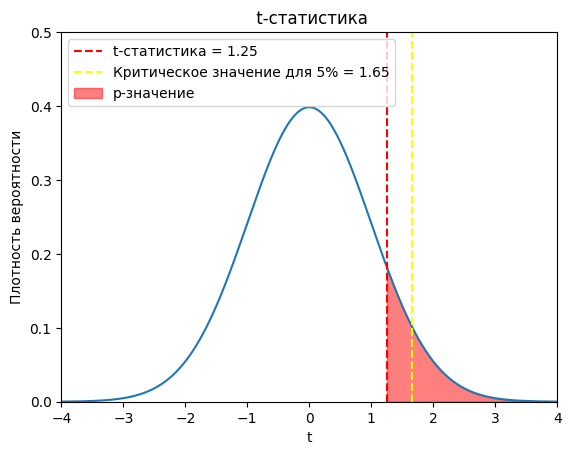

In [62]:
#5
alphas = (.05,)
mean = 50
std = 8
sample_n = 25
sample_mean = 52
sample_std = std

t_score = (sample_mean - mean) / (sample_std / np.sqrt(sample_n))
df = n-1
p_value = 1 - stats.t.cdf(t_score, df)

print(f"t-статистика: {t_score:.4f}")
print(f"p-значение: {p_value:.4f}")

for alpha in alphas: 
    compare(p_value, alpha)


t_min, t_max = -4, 4
t_value = np.linspace(t_min, t_max, 1000)
pdf = stats.t.pdf(t_value, df)
plt.plot(t_value, pdf)

plt.axvline(t_score, color='red', linestyle='--', label=f't-статистика = {t_score:.2f}')

for alpha, color in zip(alphas, ('yellow', 'green')):
    t_crit = stats.t.ppf(1-alpha, df)
    plt.axvline(t_crit, color=color, linestyle='--', label=f'Критическое значение для {alpha*100:.0f}% = {t_crit:.2f}')

plt.fill_between(t_value, pdf, where=(t_value >= abs(t_score)), color='red', alpha=0.5, label='p-значение')

plt.xlim(t_min, t_max)
plt.ylim(0, 0.5)
plt.legend()
plt.title(' t-статистика')
plt.xlabel('t')
_ = plt.ylabel('Плотность вероятности')


### Задача 15 (3 балла за все пункты)

Задача 1. Компания оценивает эффективность нового программного обеспечения для повышения производительности сотрудников. Перед установкой ПО среднее время выполнения определённой задачи у 60 сотрудников составляло 100 минут с известным стандартным отклонением 12 минут. После установки нового ПО среднее время выполнения той же задачи снизилось до 95 минут. Считаем, что стандартное отклонение осталось неизменным. Можно ли на уровне значимости α = 5% утверждать, что новое ПО действительно снижает время выполнения задачи? Сформулируйте нулевую и альтернативную гипотезы, определите тип теста и проверьте нулевую гипотезу.


---

Задача 2. Решите задачу 1, если стандартное отклонение после установки нового ПО неизвестно, а выборка составляет 25 сотрудников. По полученным данным несмещённая оценка дисперсии после установки ПО составляет 144 минуты².


---

Задача 3. Компания сравнивает эффективность двух независимых групп сотрудников: первая группа из 50 человек использует старое ПО, вторая группа из 50 человек — новое ПО. Среднее время выполнения задачи в первой группе составляет 100 минут со стандартным отклонением 12 минут, во второй группе — 95 минут со стандартным отклонением 12 минут. Можно ли на уровне значимости α = 5% утверждать, что новое ПО снижает время выполнения задачи по сравнению со старым?


---

Задача 4. Для оценки влияния обучающего курса на навыки сотрудников компания измеряет время выполнения задачи у 30 сотрудников до и после прохождения курса. Среднее время до обучения составляет 80 минут, после обучения — 75 минут. Известно, что стандартное отклонение разностей времени (до и после) составляет 5 минут. Можно ли на уровне значимости α = 1% утверждать, что обучение улучшило навыки сотрудников? Сформулируйте нулевую и альтернативную гипотезы и выберите подходящий статистический тест.


---

Задача 5. Решите задачу 4, если стандартное отклонение разностей времени неизвестно, а несмещённая оценка дисперсии разностей составляет 25 минут². Примите уровень значимости равным 1%.

z-статистика: 3.23
p-значение: 0.9994
Нет оснований отклонить нулевую гипотезу H0: среднее время не изменилось.


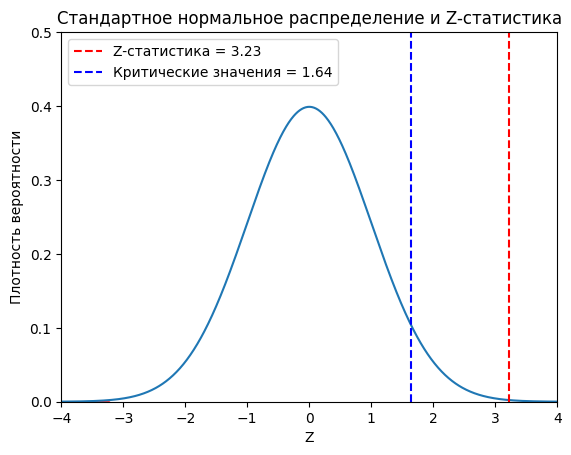

In [63]:
alpha = 0.05

n = 60
mean_before = 100
mean_after = 95
std = 12


z_score = (mean_before - mean_after) / (std / (n ** 0.5))
z_critical = stats.norm.ppf(1 - alpha)
p_value = stats.norm.cdf(z_score)

print(f"z-статистика: {z_score:.2f}")
print(f"p-значение: {p_value:.4f}")

plot_z(
    z_score,
    z_critical,
    'left'
)

if p_value < alpha:
    print("Отклоняем нулевую гипотезу H0: принимаем альтернативную гипотезу: среднее время снизилось.")
else:
    print("Нет оснований отклонить нулевую гипотезу H0: среднее время не изменилось.")


t-статистика: 1.47
p-значение: 0.9264
Нет оснований отклонить нулевую гипотезу H0: среднее время не изменилось.


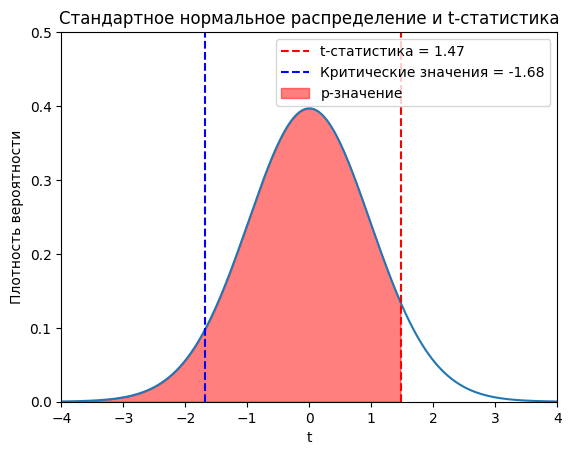

In [64]:
alpha = 0.05

n = 25
mean_before = 100
mean_after = 95
std = 12

t_score = (mean_before - mean_after) / np.sqrt((std**2 / n) + (std**2 / n))
df = n + n - 2

p_value = stats.t.cdf(t_score, df)

print(f"t-статистика: {t_score:.2f}")
print(f"p-значение: {p_value:.4f}")

if p_value < alpha:
    print("Отклоняем нулевую гипотезу H0 и принимаем альтернативную гипотезу: среднее время снизилось.")
else:
    print("Нет оснований отклонить нулевую гипотезу H0: среднее время не изменилось.")

plot_t(
    t_score,
    stats.t.ppf(alpha, df),
    df,
    'left'
)


z-статистика: 2.08
p-значение: 0.9814
Нет оснований отклонить нулевую гипотезу H0: среднее время не изменилось.


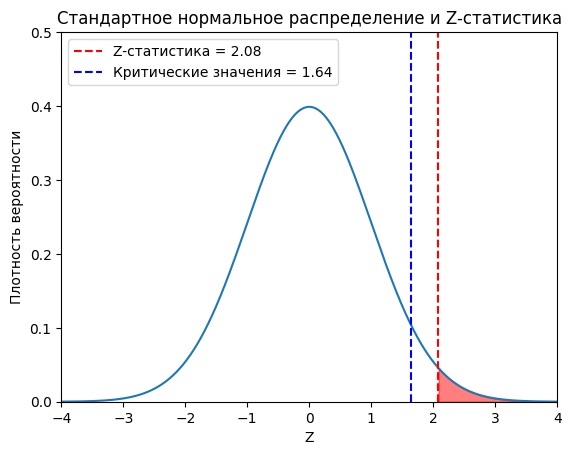

In [65]:
alpha = 0.05

n = 50
mean_before = 100
mean_after = 95
std = 12

z_score = (mean_before - mean_after) / np.sqrt((std**2 / n) + (std**2 / n))
z_critical = stats.norm.ppf(1 - alpha)
p_value = stats.norm.cdf(z_score)

print(f"z-статистика: {z_score:.2f}")
print(f"p-значение: {p_value:.4f}")

plot_z(
    z_score,
    z_critical,
    'right'
)

if p_value < alpha:
    print("Отклоняем нулевую гипотезу H0: принимаем альтернативную гипотезу: среднее время снизилось.")
else:
    print("Нет оснований отклонить нулевую гипотезу H0: среднее время не изменилось.")


t-статистика: 5.4772
p-значение: 0.999997
Не отвергаем нулевую гипотезу H0 (нет достаточных оснований считать, что программа снизила время выполнения задачи)


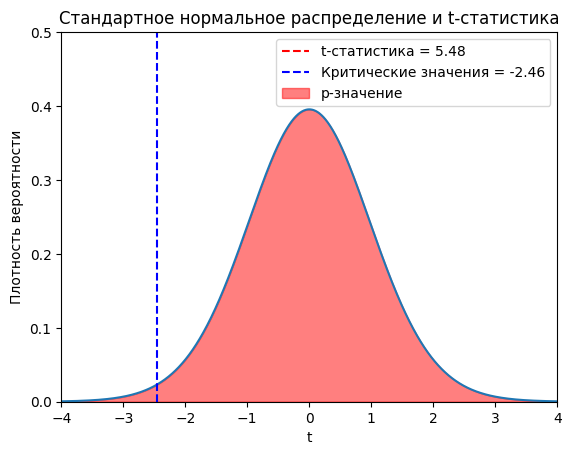

In [66]:
n = 30
mean_before = 80
mean_after = 75
std = 5
alpha = 0.01

t_score = (mean_before - mean_after) / (std / (n ** 0.5))
df = n - 1
p_value = stats.t.cdf(t_score, df)

print(f"t-статистика: {t_score:.4f}")
print(f"p-значение: {p_value:.6f}")
if p_value <= alpha:
    print("Отвергаем нулевую гипотезу H0 (программа снизила время выполнения задачи)")
else:
    print("Не отвергаем нулевую гипотезу H0 (нет достаточных оснований считать, что программа снизила время выполнения задачи)")

plot_t(
    t_score,
    stats.t.ppf(alpha, df),
    df=df,
    kind='left'
)


t-статистика: 5.4772
p-значение: 0.999997
Нет оснований отклонить нулевую гипотезу H0: время выполнения не изменилось.


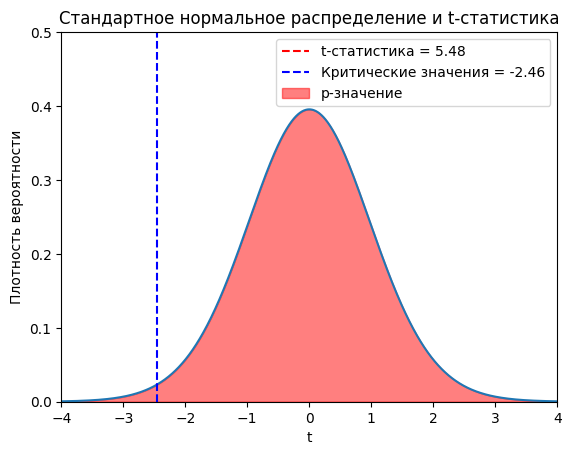

In [67]:
alpha = .01

n = 30
mean_before = 80
mean_after = 75
std = 5

t_score = (mean_before - mean_after) / (std / (n ** 0.5))

df = n - 1
p_value = stats.t.cdf(t_score, df)

print(f"t-статистика: {t_score:.4f}")
print(f"p-значение: {p_value:.6f}")

if p_value < alpha:
    print("Отклоняем нулевую гипотезу H0 и принимаем альтернативную гипотезу: время выполнения снизилось.")
else:
    print("Нет оснований отклонить нулевую гипотезу H0: время выполнения не изменилось.")

plot_t(
    t_score,
    stats.t.ppf(alpha, df),
    df,
    'left'
)

### Задача 16 (4 балла за все пункты)

Монетку подбросили n=150 раз. Из них выпало Y орлов. Вероятность выпадения орла равна p.

(a) При каких значениях Y вы отвергнете нулевую гипотезу H0:p=1/2 против односторонней альтернативы p>1/2 на уровне значимости α=0.05?

(b) Предположим, что на самом деле H0​ не выполняется, а выполняется H1​, и вероятность выпадения орла равна p=1/2+δ, где δ=1/10. При этом мы не знаем точное значение p, но действуем согласно нашему критерию. С какой вероятностью мы при этом отвергнем гипотезу H0​? Какова вероятность совершить ошибку второго рода (не отвергнуть H0​, когда H1​ истинна)?

(c) Решите ту же задачу для δ=1/100.

(d) Решите ту же задачу для δ=1/100 и n=1000.

In [68]:
alpha = .05

n = 150
p = .5

z-критическое: 1.6448536269514722
Минимальное возможное кл-во орлов: 86


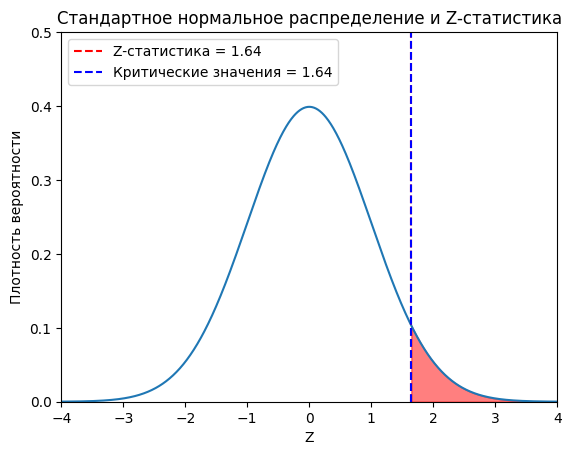

In [69]:
mean = n * p
std = np.sqrt(n* p * (1 - p))
z_critical = stats.norm.ppf(1 - alpha)
print("z-критическое:", z_critical)

N = np.ceil(mean + z_critical * std)
print(f"Минимальное возможное кл-во орлов: {N:.0f}")

plot_z(
    z_critical,
    z_critical,
    'right'
)

In [70]:
alpha = .05

delta = 1/10
pb = 1/2 + delta

z_critical = stats.norm.ppf(1 - alpha)

std = np.sqrt(p * (1 - p) / n)
n_ = np.ceil((z_critical + p / std) * n * std)
print(f"Минимальное значение Y для отклонения H0: {n_}")

z_power = (n_ - n * pb) / np.sqrt(n * pb * (1 - pb))
power = 1 - stats.norm.cdf(z_power)

betta = 1 - power

print(f"Вероятность ошибки второго рода = {betta:.4f}")

Минимальное значение Y для отклонения H0: 86.0
Вероятность ошибки второго рода = 0.2525


In [71]:
alpha = .05

n = 150
delta = 1/100
pb = 1/2 + delta

z_critical = stats.norm.ppf(1 - alpha)

std = np.sqrt(p * (1 - p) / n)
n_ = np.ceil((z_critical + p / std) * n * std)
print(f"Минимальное значение Y для отклонения H0: {n_}")

z_power = (n_ - n * pb) / np.sqrt(n * pb * (1 - pb))
power = 1 - stats.norm.cdf(z_power)

betta = 1 - power

print(f"Вероятность ошибки второго рода = {betta:.4f}")

Минимальное значение Y для отклонения H0: 86.0
Вероятность ошибки второго рода = 0.9396


In [72]:
alpha = .05

n = 1000
delta = 1/100
pb = 1/2 + delta

z_critical = stats.norm.ppf(1 - alpha)

std = np.sqrt(p * (1 - p) / n)
n_ = np.ceil((z_critical + p / std) * n * std)
print(f"Минимальное значение Y для отклонения H0: {n_}")

z_power = (n_ - n * pb) / np.sqrt(n * pb * (1 - pb))
power = 1 - stats.norm.cdf(z_power)

betta = 1 - power

print(f"Вероятность ошибки второго рода = {betta:.4f}")

Минимальное значение Y для отклонения H0: 527.0
Вероятность ошибки второго рода = 0.8589
